<a href="https://colab.research.google.com/github/rameelarustam47/flood-segmentation-swat-valley-unet/blob/main/XG%20boost%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported!
XGBoost version: 3.2.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files loaded!
Resized to: (1857, 1857)
Total pixels : 3438927
Flood pixels : 21220
No Flood     : 3417707
After SMOTE:
Flood   : 63660
No Flood: 63660
Total   : 127320
Train: 101856
Test : 25464

XGBoost model created!
Training started...
[0]	validation_0-logloss:0.60577
[10]	validation_0-logloss:0.31486


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:27:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[20]	validation_0-logloss:0.19557
[30]	validation_0-logloss:0.10724
[40]	validation_0-logloss:0.07198
[50]	validation_0-logloss:0.05011
[60]	validation_0-logloss:0.04219
[70]	validation_0-logloss:0.03233
[80]	validation_0-logloss:0.02768
[90]	validation_0-logloss:0.02224
[99]	validation_0-logloss:0.02010
Training complete!

Test Accuracy : 99.58%

Classification Report:
              precision    recall  f1-score   support

    No Flood       1.00      0.99      1.00     12852
       Flood       0.99      1.00      1.00     12612

    accuracy                           1.00     25464
   macro avg       1.00      1.00      1.00     25464
weighted avg       1.00      1.00      1.00     25464



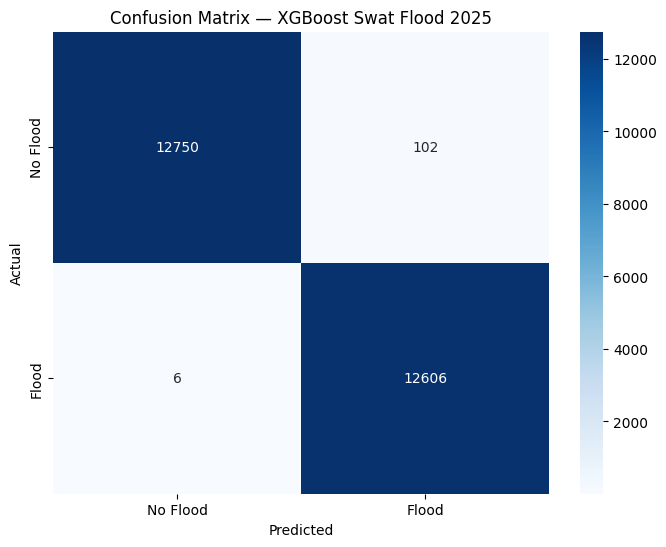

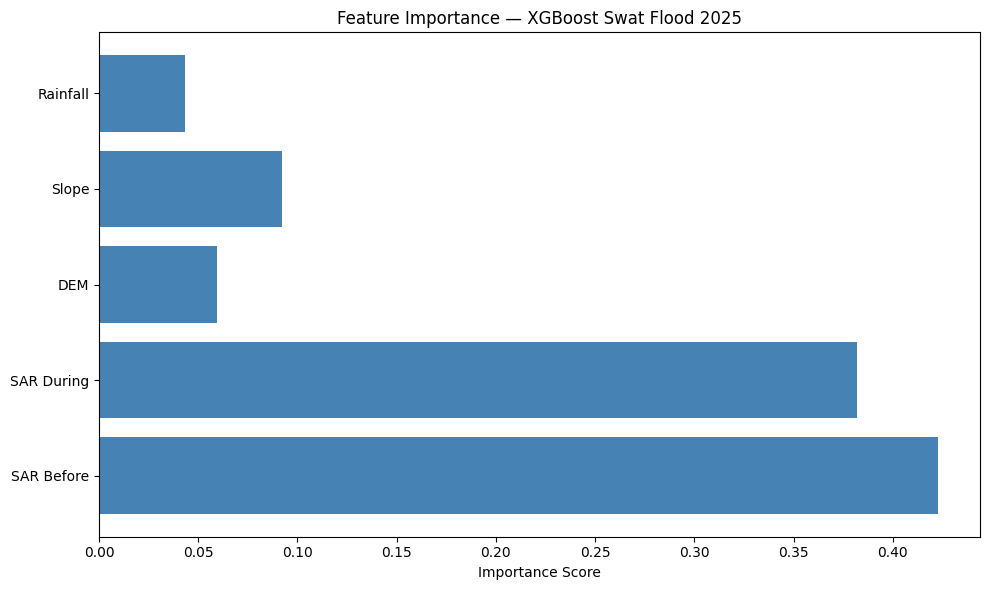


Feature Importance:
-----------------------------------
SAR Before      : 0.4228
SAR During      : 0.3821
DEM             : 0.0593
Slope           : 0.0923
Rainfall        : 0.0435


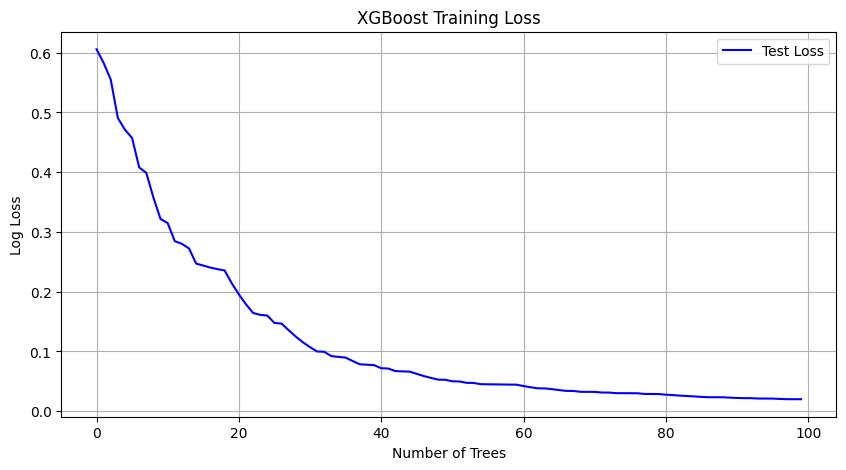

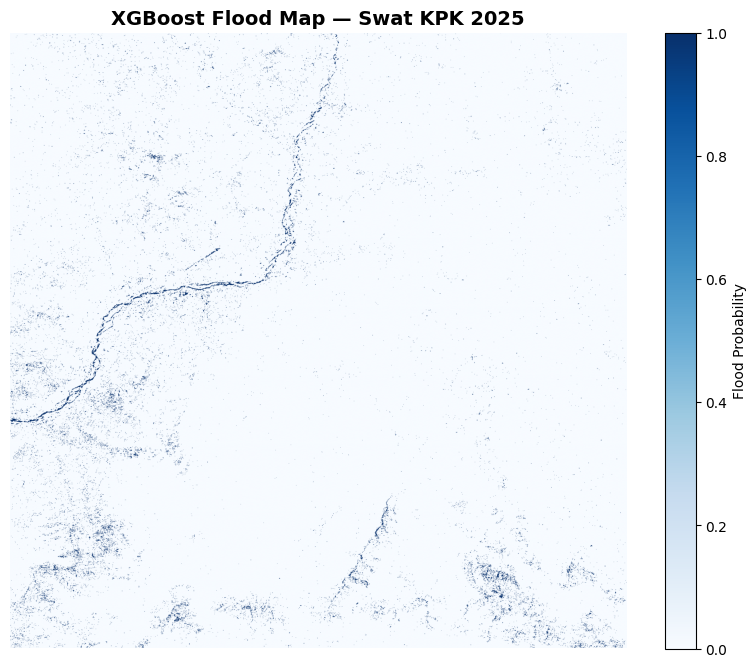

Flood map saved!

Model saved!
Project Complete!
  adding: images/ (stored 0%)
  adding: images/training_curve_xgboost.png (deflated 22%)
  adding: images/xgboost_flood_map.png (deflated 3%)
  adding: images/feature_importance_xgboost.png (deflated 36%)
  adding: images/confusion_matrix_xgboost.png (deflated 28%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# SWAT FLOOD PREDICTION - XGBOOST
# ============================================

# STEP 1 - INSTALL AND IMPORT
!pip install rasterio --quiet
!pip install xgboost --quiet
!pip install imbalanced-learn --quiet

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.transform import resize
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import xgboost as xgb
import os
os.makedirs("images", exist_ok=True)
print("All libraries imported!")
print("XGBoost version:", xgb.__version__)

# STEP 2 - MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

# STEP 3 - SET PATH
path = '/content/drive/MyDrive/swat_flood_2025/'

# STEP 4 - READ ALL FILES
with rasterio.open(path + 'Swat_SAR_Before_2025.tif') as src:
    sar_before = src.read(1).astype(float)
with rasterio.open(path + 'Swat_SAR_During_2025.tif') as src:
    sar_during = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Flood_Extent_Fixed.tif') as src:
    flood_label = src.read(1).astype(float)
with rasterio.open(path + 'Swat_DEM_2025.tif') as src:
    dem = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Slope_2025.tif') as src:
    slope = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Rainfall_CHIRPS_2025.tif') as src:
    rainfall = src.read(1).astype(float)
print("All files loaded!")

# STEP 5 - RESIZE
target = sar_before.shape
sar_during  = resize(sar_during,  target)
flood_label = resize(flood_label, target)
dem         = resize(dem,         target)
slope       = resize(slope,       target)
rainfall    = resize(rainfall,    target)
print("Resized to:", target)

# STEP 6 - PREPARE DATA
X = np.column_stack([
    sar_before.flatten(),
    sar_during.flatten(),
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])
y = flood_label.flatten()

# Remove NaN
valid = (
    np.isfinite(X).all(axis=1) &
    np.isfinite(y)
)
X = X[valid]
y = (y[valid] > 0.5).astype(int)

print("Total pixels :", X.shape[0])
print("Flood pixels :", (y==1).sum())
print("No Flood     :", (y==0).sum())

# STEP 7 - BALANCE WITH SMOTE
X_flood   = X[y==1]
y_flood   = y[y==1]
X_noflood = X[y==0]
y_noflood = y[y==0]

# Reduce no flood to 3x flood
X_noflood, y_noflood = resample(
    X_noflood, y_noflood,
    n_samples=len(X_flood)*3,
    random_state=42
)

X = np.vstack([X_flood, X_noflood])
y = np.hstack([y_flood, y_noflood])

# Apply SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("After SMOTE:")
print("Flood   :", (y==1).sum())
print("No Flood:", (y==0).sum())
print("Total   :", X.shape[0])

# STEP 8 - SPLIT AND SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("Train:", X_train.shape[0])
print("Test :", X_test.shape[0])

# STEP 9 - BUILD XGBOOST MODEL
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
print("\nXGBoost model created!")
print("Training started...")

# STEP 10 - TRAIN MODEL
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)
print("Training complete!")

# STEP 11 - EVALUATE
predictions = model.predict(X_test)
accuracy = (predictions == y_test).mean()
print(f"\nTest Accuracy : {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test, predictions,
    target_names=['No Flood','Flood']
))

# STEP 12 - CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Flood','Flood'],
    yticklabels=['No Flood','Flood']
)
plt.title('Confusion Matrix — XGBoost Swat Flood 2025')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('images/confusion_matrix_xgboost.png', dpi=300)
plt.show()

# STEP 13 - FEATURE IMPORTANCE
plt.figure(figsize=(10,6))
features = [
    'SAR Before',
    'SAR During',
    'DEM',
    'Slope',
    'Rainfall'
]
importance = model.feature_importances_
plt.barh(features, importance, color='steelblue')
plt.title('Feature Importance — XGBoost Swat Flood 2025')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/feature_importance_xgboost.png', dpi=300)
plt.show()

# Print feature importance
print("\nFeature Importance:")
print("-" * 35)
for f, i in zip(features, importance):
    print(f"{f:15s} : {i:.4f}")

# STEP 14 - TRAINING CURVE
results = model.evals_result()
plt.figure(figsize=(10,5))
plt.plot(results['validation_0']['logloss'],
         label='Test Loss',
         color='blue')
plt.title('XGBoost Training Loss')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.savefig('images/training_curve_xgboost.png', dpi=300)
plt.show()

# STEP 15 - PREDICT FLOOD MAP
X_all = np.column_stack([
    sar_before.flatten(),
    sar_during.flatten(),
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])

valid_all = np.isfinite(X_all).all(axis=1)
flood_map = np.zeros(X_all.shape[0])
flood_map[valid_all] = model.predict(
    scaler.transform(X_all[valid_all])
)

flood_map = flood_map.reshape(sar_before.shape)

plt.figure(figsize=(10,8))
plt.imshow(flood_map, cmap='Blues')
plt.colorbar(label='Flood Probability')
plt.title('XGBoost Flood Map — Swat KPK 2025',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.savefig('images/xgboost_flood_map.png', dpi=300)
plt.show()
print("Flood map saved!")

# STEP 16 - SAVE MODEL
import joblib
joblib.dump(model, 'swat_xgboost_model.pkl')
joblib.dump(scaler, 'scaler_xgboost.pkl')
print("\nModel saved!")
print("Project Complete!")
!zip -r images.zip images
from google.colab import files
files.download("images.zip")

In [5]:
from google.colab import files

# Upload TensorFlow map from your computer
uploaded = files.upload()

Saving confusion_matrix_xgboost.png to confusion_matrix_xgboost.png
Saving training_curve_xgboost.png to training_curve_xgboost.png
Saving xgboost_flood_map.png to xgboost_flood_map.png
Saving flood_prediction_map_tensorflow.png to flood_prediction_map_tensorflow (1).png
Saving confusion_matrix_tensorflow.png to confusion_matrix_tensorflow (1).png
Saving training_results_tensorflow.png to training_results_tensorflow (1).png


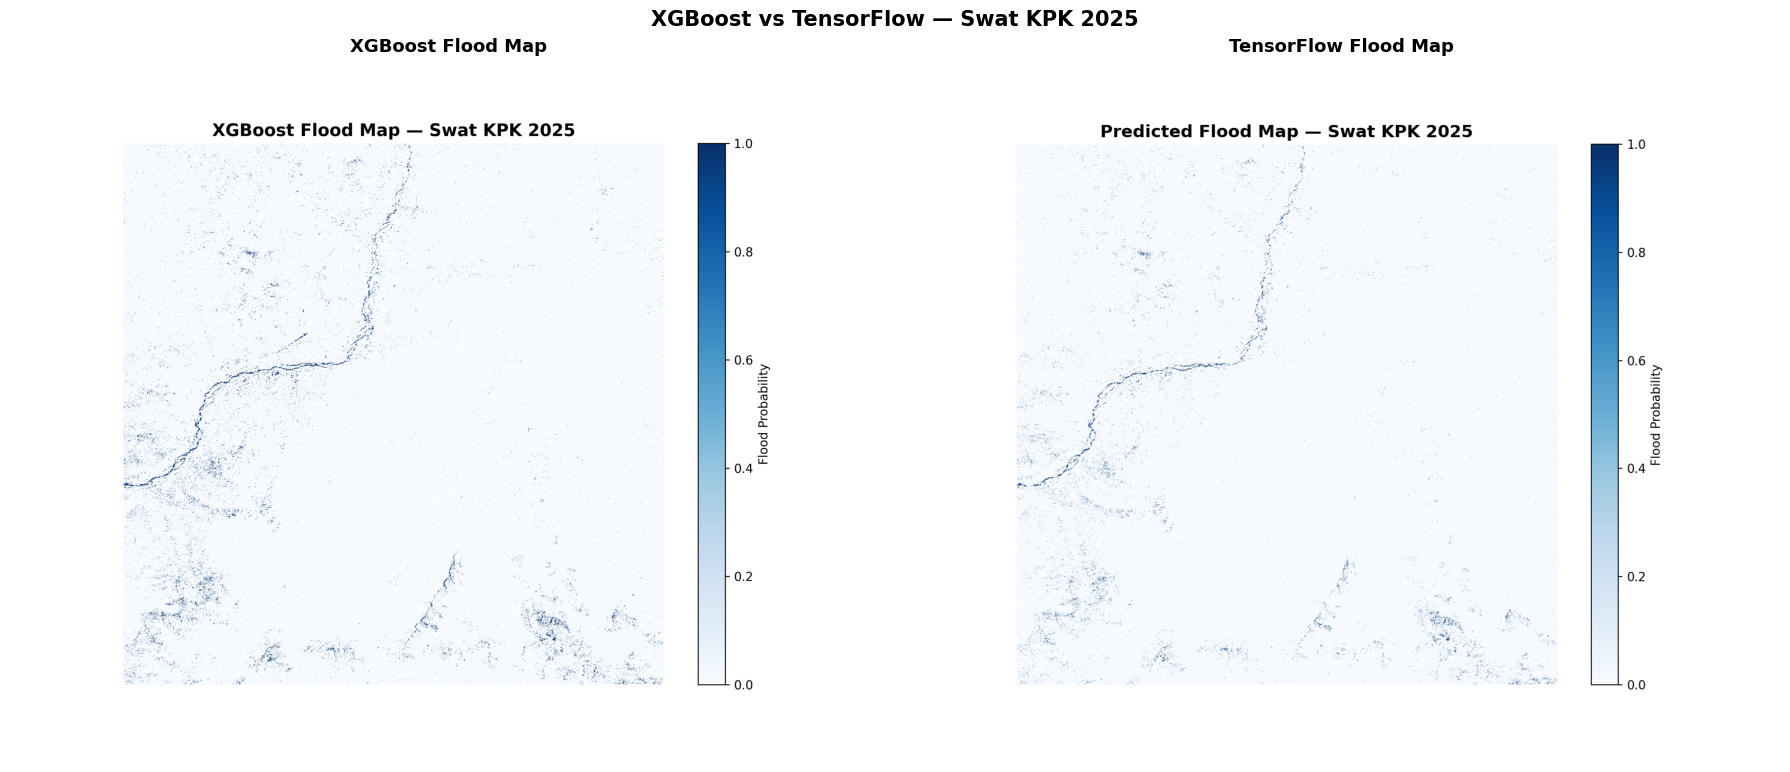

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
xgb_map = plt.imread('xgboost_flood_map.png')
tf_map  = plt.imread('flood_prediction_map_tensorflow.png')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(xgb_map)
axes[0].set_title('XGBoost Flood Map', fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(tf_map)
axes[1].set_title('TensorFlow Flood Map', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('XGBoost vs TensorFlow — Swat KPK 2025',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('flood_map_comparison.png', dpi=300)
plt.show()

files.download('flood_map_comparison.png')